# Instructor Git Study Agent

강사님 Git 저장소에서 지정한 날짜의 변경 파일을 찾아 수업 내용을 정리하는 LangGraph 에이전트이다.

## 실행 흐름

```text
저장소 동기화
→ 날짜별 변경 파일 수집
→ Notebook/코드 파싱
→ 파일별 핵심 내용 분석
→ 통합 수업 노트 작성
→ 품질 검토
   ├─ 통과 → 복습 자료 생성
   └─ 보완 필요 → 보고서 수정 → 복습 자료 생성
```


## 1. 준비 사항

- PC에 Git이 설치되어 있어야 한다.
- `.env` 파일에 `OPENAI_API_KEY`를 설정한다.
- 공개 Git 저장소는 GitHub 토큰 없이 가져올 수 있다.
- 노트북의 실행 결과(outputs)는 분석에서 제외한다.

In [1]:
from __future__ import annotations

from datetime import datetime, timedelta
from pathlib import Path
from typing import TypedDict
import json
import os
import subprocess
import tempfile

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

load_dotenv()

if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError(".env 파일에 OPENAI_API_KEY를 설정하세요.")

MODEL_NAME = "gpt-5.4-mini"
llm = init_chat_model(MODEL_NAME, reasoning_effort="none")

print(f"모델: {MODEL_NAME}")

모델: gpt-5.4-mini


## 2. 분석할 저장소와 날짜 설정

날짜는 한국 시간 기준 `YYYY-MM-DD` 형식으로 입력한다.

In [2]:
REPO_URL = "https://github.com/skn-ai34-260616/LLM.git"
STUDY_DATE = "2026-09-04"
LEARNER_LEVEL = "수업을 일부 놓친 초보자"
MAX_CHARS_PER_FILE = 18_000

# 어느 하위 폴더에서 실행해도 현재 study Git 저장소의 루트를 찾는다.
def find_workspace_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / ".git").exists():
            return candidate
    return current


WORKSPACE_ROOT = find_workspace_root(Path.cwd())
# 복제 저장소는 우리 Git 변경 목록에 들어오지 않도록 Windows 임시 폴더에 보관한다.
CACHE_DIR = Path(tempfile.gettempdir()) / "skn34-instructor-llm-study-agent"

print(f"저장소: {REPO_URL}")
print(f"수업 날짜: {STUDY_DATE}")
print(f"캐시 경로: {CACHE_DIR.resolve()}")

저장소: https://github.com/skn-ai34-260616/LLM.git
수업 날짜: 2026-09-04
캐시 경로: C:\Users\MoonSungHo\AppData\Local\Temp\skn34-instructor-llm-study-agent


## 3. Git 및 파일 처리 도구

에이전트가 사용할 로컬 도구를 정의한다. Git 명령은 인자 리스트로 실행하고 셸 문자열을 사용하지 않는다.

In [3]:
def run_git(args: list[str], cwd: Path | None = None) -> str:
    """Git 명령을 실행하고 표준 출력을 반환한다."""
    command = ["git", *args]
    result = subprocess.run(
        command,
        cwd=cwd,
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace",
        check=False,
    )
    if result.returncode != 0:
        raise RuntimeError(
            f"Git 명령 실패: {' '.join(command)}\n{result.stderr.strip()}"
        )
    return result.stdout.strip()


@tool
def sync_repository(repo_url: str) -> str:
    """공개 Git 저장소를 로컬 캐시에 복제하거나 최신 상태로 갱신한다."""
    CACHE_DIR.parent.mkdir(parents=True, exist_ok=True)

    if (CACHE_DIR / ".git").exists():
        run_git(["fetch", "origin", "main"], cwd=CACHE_DIR)
        run_git(["checkout", "-f", "main"], cwd=CACHE_DIR)
        run_git(["reset", "--hard", "origin/main"], cwd=CACHE_DIR)
        action = "updated"
    else:
        run_git(["clone", "--filter=blob:none", repo_url, str(CACHE_DIR)])
        action = "cloned"

    head = run_git(["rev-parse", "--short", "HEAD"], cwd=CACHE_DIR)
    return json.dumps(
        {"action": action, "cache_dir": str(CACHE_DIR), "head": head},
        ensure_ascii=False,
    )


@tool
def find_changed_files(study_date: str) -> str:
    """해당 날짜(한국 시간)에 변경된 학습 파일과 최신 커밋을 찾는다."""
    start = datetime.strptime(study_date, "%Y-%m-%d")
    end = start + timedelta(days=1)

    since = start.strftime("%Y-%m-%dT00:00:00+09:00")
    until = end.strftime("%Y-%m-%dT00:00:00+09:00")

    commits_text = run_git(
        [
            "log",
            f"--since={since}",
            f"--until={until}",
            "--format=%H",
        ],
        cwd=CACHE_DIR,
    )
    commits = [line for line in commits_text.splitlines() if line]

    # git log는 최신 커밋부터 반환한다. 같은 파일은 가장 최신 버전을 선택한다.
    latest_files: dict[str, str] = {}
    allowed_suffixes = {".ipynb", ".py", ".md"}

    for commit in commits:
        names = run_git(
            ["show", "--pretty=format:", "--name-only", commit],
            cwd=CACHE_DIR,
        )
        for name in names.splitlines():
            path = name.strip()
            if path and Path(path).suffix.lower() in allowed_suffixes:
                latest_files.setdefault(path, commit)

    result = {
        "study_date": study_date,
        "commits": commits,
        "files": [
            {"path": path, "commit": commit}
            for path, commit in sorted(latest_files.items())
        ],
    }
    return json.dumps(result, ensure_ascii=False)

In [4]:
def notebook_to_text(raw_text: str) -> str:
    """ipynb에서 Markdown과 코드 셀만 추출하고 실행 출력은 제외한다."""
    notebook = json.loads(raw_text)
    sections: list[str] = []

    for index, cell in enumerate(notebook.get("cells", [])):
        cell_type = cell.get("cell_type", "unknown")
        if cell_type not in {"markdown", "code"}:
            continue

        source = cell.get("source", [])
        text = "".join(source) if isinstance(source, list) else str(source)
        text = text.strip()
        if text:
            sections.append(
                f"[{cell_type.upper()} CELL {index}]\n{text}"
            )

    return "\n\n".join(sections)


@tool
def load_learning_file(file_path: str, commit: str) -> str:
    """특정 커밋 시점의 학습 파일을 읽고 분석 가능한 텍스트로 변환한다."""
    raw_text = run_git(["show", f"{commit}:{file_path}"], cwd=CACHE_DIR)

    if file_path.lower().endswith(".ipynb"):
        content = notebook_to_text(raw_text)
    else:
        content = raw_text

    truncated = len(content) > MAX_CHARS_PER_FILE
    content = content[:MAX_CHARS_PER_FILE]

    return json.dumps(
        {
            "path": file_path,
            "commit": commit[:8],
            "content": content,
            "truncated": truncated,
        },
        ensure_ascii=False,
    )

## 4. LangGraph 상태 정의

각 노드가 저장소 정보, 변경 파일, 파일별 분석, 통합 보고서와 검토 결과를 공유한다.

In [5]:
class StudyAgentState(TypedDict, total=False):
    repo_url: str
    study_date: str
    learner_level: str
    commits: list[str]
    files: list[dict]
    materials: list[dict]
    file_summaries: list[dict]
    draft_report: str
    review_passed: bool
    review_feedback: str
    final_report: str
    review_notes: str
    error: str


class ReviewResult(BaseModel):
    passed: bool = Field(description="핵심 내용이 빠짐없이 명확하면 true")
    feedback: str = Field(description="부족한 내용과 구체적인 보완 지시")

## 5. 에이전트 노드 구현

In [6]:
def collect_materials(state: StudyAgentState):
    """저장소를 동기화하고 지정 날짜의 변경 파일 내용을 수집한다."""
    try:
        sync_result = json.loads(
            sync_repository.invoke({"repo_url": state["repo_url"]})
        )
        change_result = json.loads(
            find_changed_files.invoke({"study_date": state["study_date"]})
        )

        materials = [
            json.loads(
                load_learning_file.invoke(
                    {
                        "file_path": item["path"],
                        "commit": item["commit"],
                    }
                )
            )
            for item in change_result["files"]
        ]

        return {
            "commits": change_result["commits"],
            "files": change_result["files"],
            "materials": materials,
            "review_notes": (
                f"저장소 {sync_result['action']}, HEAD={sync_result['head']}"
            ),
        }
    except Exception as error:
        return {"error": str(error)}

In [7]:
FILE_ANALYSIS_PROMPT = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 AI 부트캠프 수업자료를 분석하는 교육 전문가입니다.
학습자가 실제 코드를 다시 실행할 수 있도록 정확하고 구체적으로 설명하세요.
자료에 없는 내용을 수업 내용인 것처럼 만들지 마세요.""",
    ),
    (
        "human",
        """학습자 수준: {learner_level}
파일: {file_path}

다음 수업자료를 분석하세요.

{content}

아래 항목으로 정리하세요.
1. 이 파일의 학습 목표
2. 핵심 개념
3. 코드 실행 흐름
4. 중요한 클래스·함수·도구
5. 실행 전 필요한 환경·API·데이터
6. 예상 오류와 확인할 부분
7. 직접 해볼 작은 실습""",
    ),
])


def analyze_files(state: StudyAgentState):
    """변경된 파일별로 학습 내용을 분석한다."""
    if state.get("error"):
        return {}

    if not state.get("materials"):
        return {
            "error": (
                f"{state['study_date']}에 분석 가능한 .ipynb/.py/.md 변경 파일이 없습니다."
            )
        }

    chain = FILE_ANALYSIS_PROMPT | llm
    summaries = []

    for material in state["materials"]:
        response = chain.invoke(
            {
                "learner_level": state["learner_level"],
                "file_path": material["path"],
                "content": material["content"],
            }
        )
        summaries.append(
            {
                "path": material["path"],
                "commit": material["commit"],
                "truncated": material["truncated"],
                "summary": response.content,
            }
        )

    return {"file_summaries": summaries}

In [8]:
REPORT_PROMPT = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 여러 수업 파일의 분석을 하나의 학습 노트로 편집합니다.
중복 설명은 합치고, 파일 사이의 선후 관계와 전체 실행 흐름을 분명히 보여주세요.
초보자가 복습할 수 있으면서 취업 포트폴리오 회고에도 활용할 수 있게 작성하세요.""",
    ),
    (
        "human",
        """수업 날짜: {study_date}
학습자 수준: {learner_level}
변경 커밋: {commits}

파일별 분석:
{summaries}

다음 구조의 한국어 Markdown 보고서를 작성하세요.

# 날짜별 수업 정리
## 오늘의 핵심 한 문장
## 전체 수업 흐름
## 파일별 학습 내용
## 핵심 코드와 개념
## 이전 학습과의 연결
## 실행 체크리스트
## 내가 직접 해볼 실습
## 포트폴리오 회고 포인트

변경된 파일 경로를 반드시 표시하세요.""",
    ),
])


def compile_report(state: StudyAgentState):
    """파일별 분석을 날짜별 통합 수업 노트로 작성한다."""
    if state.get("error"):
        return {}

    summary_text = "\n\n".join(
        f"### {item['path']}\n{item['summary']}"
        for item in state["file_summaries"]
    )

    response = (REPORT_PROMPT | llm).invoke(
        {
            "study_date": state["study_date"],
            "learner_level": state["learner_level"],
            "commits": ", ".join(commit[:8] for commit in state["commits"]),
            "summaries": summary_text,
        }
    )
    return {"draft_report": response.content}

In [9]:
REVIEW_PROMPT = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 수업 요약 품질 검토자입니다.
원본 파일별 분석과 통합 보고서를 비교해 누락, 잘못된 연결, 실행 정보 부족을 검사하세요.""",
    ),
    (
        "human",
        """파일별 분석:
{summaries}

통합 보고서:
{report}

다음 기준을 모두 만족하면 passed=true로 평가하세요.
- 모든 변경 파일이 언급됨
- 핵심 개념과 코드 흐름이 포함됨
- 필요한 API·데이터·환경이 포함됨
- 자료에 없는 사실을 단정하지 않음
- 학습자가 실행할 다음 단계가 명확함""",
    ),
])


def review_report(state: StudyAgentState):
    """구조화 출력으로 통합 보고서의 품질을 평가한다."""
    summary_text = "\n\n".join(
        f"### {item['path']}\n{item['summary']}"
        for item in state["file_summaries"]
    )
    reviewer = llm.with_structured_output(ReviewResult)
    result = (REVIEW_PROMPT | reviewer).invoke(
        {
            "summaries": summary_text,
            "report": state["draft_report"],
        }
    )
    return {
        "review_passed": result.passed,
        "review_feedback": result.feedback,
    }


def route_after_review(state: StudyAgentState):
    return "finish" if state.get("review_passed") else "revise"

In [10]:
REVISION_PROMPT = ChatPromptTemplate.from_messages([
    (
        "system",
        "품질 검토 의견을 반영해 수업 보고서를 정확하고 완결된 Markdown 문서로 수정하세요.",
    ),
    (
        "human",
        """기존 보고서:
{report}

검토 의견:
{feedback}

기존 보고서의 유용한 내용은 유지하고 지적받은 부분만 명확하게 보완하세요.""",
    ),
])

REVIEW_MATERIAL_PROMPT = ChatPromptTemplate.from_messages([
    (
        "system",
        "수업 보고서를 바탕으로 학습자가 스스로 이해도를 점검할 복습 자료를 만드세요.",
    ),
    (
        "human",
        """수업 보고서:
{report}

다음을 한국어 Markdown으로 작성하세요.
## 복습 문제
- 개념 확인 문제 3개
- 코드 흐름 문제 2개
- 응용 문제 1개

## 정답과 해설
각 문제의 정답과 짧은 해설을 작성하세요.""",
    ),
])


def revise_report(state: StudyAgentState):
    response = (REVISION_PROMPT | llm).invoke(
        {
            "report": state["draft_report"],
            "feedback": state["review_feedback"],
        }
    )
    return {"draft_report": response.content}


def create_review_material(state: StudyAgentState):
    response = (REVIEW_MATERIAL_PROMPT | llm).invoke(
        {"report": state["draft_report"]}
    )
    final_report = (
        f"{state['draft_report']}\n\n---\n\n"
        f"{response.content}\n\n"
        f"> 자동 검토 메모: {state.get('review_feedback', '없음')}"
    )
    return {"final_report": final_report}

## 6. 그래프 조립

검토에 통과하지 못하면 보고서를 한 번 수정한 뒤 복습 자료를 생성한다.

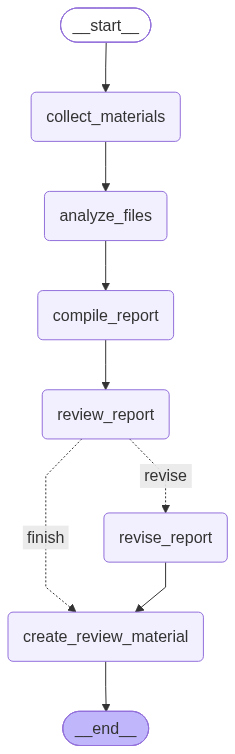

In [11]:
workflow = StateGraph(StudyAgentState)

workflow.add_node("collect_materials", collect_materials)
workflow.add_node("analyze_files", analyze_files)
workflow.add_node("compile_report", compile_report)
workflow.add_node("review_report", review_report)
workflow.add_node("revise_report", revise_report)
workflow.add_node("create_review_material", create_review_material)

workflow.add_edge(START, "collect_materials")
workflow.add_edge("collect_materials", "analyze_files")
workflow.add_edge("analyze_files", "compile_report")
workflow.add_edge("compile_report", "review_report")
workflow.add_conditional_edges(
    "review_report",
    route_after_review,
    {
        "finish": "create_review_material",
        "revise": "revise_report",
    },
)
workflow.add_edge("revise_report", "create_review_material")
workflow.add_edge("create_review_material", END)

study_agent = workflow.compile()
study_agent

## 7. 에이전트 실행

처음 실행할 때는 강사님 저장소를 복제하므로 시간이 걸릴 수 있다.

In [12]:
initial_state: StudyAgentState = {
    "repo_url": REPO_URL,
    "study_date": STUDY_DATE,
    "learner_level": LEARNER_LEVEL,
}

result = study_agent.invoke(initial_state)

if result.get("error"):
    print(f"[실행 오류]\n{result['error']}")
else:
    print(result["final_report"])

# 날짜별 수업 정리

- **수업 날짜:** 2026-09-04
- **학습자 수준:** 수업을 일부 놓친 초보자
- **변경 커밋:** `7a31e2ec`

이번 수업은 **LangGraph를 이용해 단순 RAG를 넘어서, 여러 에이전트가 역할을 나누고 서로 판단하며 실행하는 구조**를 배우는 시간이었습니다.  
핵심은 **검색, 평가, 재작성, 실행 승인**처럼 “LLM이 한 번에 답하는 것”이 아니라 **상태를 바꾸며 단계적으로 추론하는 흐름**입니다.

---

## 오늘의 핵심 한 문장

**오늘 수업은 LangGraph로 RAG, 멀티 에이전트 감독, SQL 에이전트/HITL까지 연결해, LLM을 “도구를 쓰고 판단을 분기하는 워크플로우”로 만드는 방법을 익히는 것이 핵심이었다.**

---

## 전체 수업 흐름

이번 수업은 크게 3개의 흐름으로 이어집니다.

1. **Agentic RAG**
   - 문서를 검색하고
   - 검색 결과를 평가한 뒤
   - 필요하면 질문을 다시 써서
   - 더 나은 답변을 생성

2. **Supervisor 멀티 에이전트**
   - Supervisor가 다음 작업자를 고르고
   - Researcher와 Coder가 번갈아 실행되며
   - 작업이 끝나면 종료

3. **SQL Agent + Human-in-the-loop**
   - DB 스키마를 확인하고 SQL을 생성한 뒤
   - 실제 쿼리를 실행
   - 위험한 단계는 사람 승인 후 진행

즉, 전체적으로는  
**“검색형 에이전트 → 조율형 에이전트 → 안전한 DB 에이전트”** 순서로 확장되는 수업이었습니다.

---

## 파일별 학습 내용

---

### 1) `08_langgraph/02_multi_agent/01_agentic_rag.ipynb`

이 노트북은 **LangGraph로 만드는 Agentic RAG** 예제입니다.  
초보자 관점에서 보면, 일반적인 RAG보다 한 단계 더 나아가서 **검색 결과를 보고 다시 질문을 다듬는 

## 8. 결과 저장

생성 결과를 포트폴리오 회고에 활용할 수 있도록 Markdown 파일로 저장한다.

In [13]:
if result.get("final_report"):
    output_dir = WORKSPACE_ROOT / "LLM" / "study_notes"
    output_dir.mkdir(parents=True, exist_ok=True)

    output_path = output_dir / f"{STUDY_DATE}_lesson_summary.md"
    output_path.write_text(result["final_report"], encoding="utf-8")

    print(f"저장 완료: {output_path.resolve()}")

저장 완료: C:\Users\MoonSungHo\skn34-st\study\LLM\study_notes\2026-09-04_lesson_summary.md


## 9. 확장 아이디어

- 커밋이 없는 날짜에는 가장 가까운 이전 수업일을 안내
- 파일별 요약을 벡터DB에 저장해 누적 질의응답 구현
- 이전 수업과 오늘 수업의 개념 연결
- 생성된 Markdown을 Notion 또는 블로그에 게시
- 이해도에 따라 복습 문제 난이도 조절
- 실행 오류 로그를 입력받아 관련 수업 셀 추천